In [1]:
!pip install google-play-scraper transformers torch scikit-learn wordcloud

import pandas as pd
import numpy as np
import torch
import time
import re
import matplotlib.pyplot as plt

from google_play_scraper import reviews, Sort
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00


In [2]:
## SCRAPING DATA
APP_ID = 'com.bibit.bibitid'
BATCH_SIZE = 200
MAX_DATA = 3000

all_reviews = []
continuation_token = None

while len(all_reviews) < MAX_DATA:
    result, continuation_token = reviews(
        APP_ID,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=BATCH_SIZE,
        continuation_token=continuation_token
    )

    if not result:
        break

    all_reviews.extend(result)
    print(f"Total: {len(all_reviews)}")
    time.sleep(1)

df = pd.DataFrame(all_reviews)
df = df[['content', 'score']]
df.columns = ['review', 'rating']

print("Jumlah data awal:", len(df))

Total: 200
Total: 400
Total: 600
Total: 800
Total: 1000
Total: 1200
Total: 1400
Total: 1600
Total: 1800
Total: 2000
Total: 2200
Total: 2400
Total: 2600
Total: 2800
Total: 3000
Jumlah data awal: 3000


In [3]:
## CLEANING MINIMAL
df = df[['review', 'rating']].dropna()

# buang review terlalu pendek
df = df[df['review'].str.len() > 5]

df = df.reset_index(drop=True)

print("Jumlah setelah cleaning:", len(df))

Jumlah setelah cleaning: 2600


In [4]:
df

,review,rating
0,luar biasa,5
1,pencairan dana kerekening ribet dan lama sekal...,1
2,bagus dan stabil,5
3,sangat bermanfaat,5
4,saat withdraw lemot,1
...,...,...
2595,"Pliss CS nya responya lama bgt woii ,",3
2596,min kenapa akses verifikasi masih belum centan...,1
2597,di tingkatkan lagi untuk pelayanannya,5
2598,amanah,5


In [5]:
## LABELING SENTIMEN
def label_sentiment(rating):
    if rating <= 2:
        return 0  # negatif
    elif rating == 3:
        return 1  # netral
    else:
        return 2  # positif

df['label'] = df['rating'].apply(label_sentiment)

In [6]:
## SPLIT DATA
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [7]:
## LOAD INDOBERT
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [8]:
## TOKENIZATION
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=128
)

In [9]:
## DATASET CLASS
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
test_dataset = Dataset(test_encodings, test_labels)

In [10]:
## LOAD MODEL
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
## TRAINING SETUP
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    logging_dir='./logs',
    save_strategy="epoch",
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [12]:
## TRAIN MODEL
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.475277,0.830769
2,No log,0.468574,0.830769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=260, training_loss=0.42556621844951925, metrics={'train_runtime': 131.6588, 'train_samples_per_second': 31.597, 'train_steps_per_second': 1.975, 'total_flos': 256535582284800.0, 'train_loss': 0.42556621844951925, 'epoch': 2.0})

In [13]:
## EVALUASI MODEL
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Accuracy: 0.8307692307692308

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.85      0.79       150
           1       0.00      0.00      0.00        37
           2       0.88      0.92      0.90       333

    accuracy                           0.83       520
   macro avg       0.54      0.59      0.56       520
weighted avg       0.78      0.83      0.80       520


Confusion Matrix:
 [[127   1  22]
 [ 18   0  19]
 [ 28   0 305]]


In [14]:
## PREDIKSI CONTOH
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    return torch.argmax(probs).item()

print(predict_sentiment("aplikasi ini lama banget dan sering error"))

0


# EDA

In [25]:
## CLEANING UNTUK ANALISIS (STOPWORD)

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

# tambahan
custom_stopwords = ['nya', 'aja', 'banget', 'sih', 'dong']
stop_words.update(custom_stopwords)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


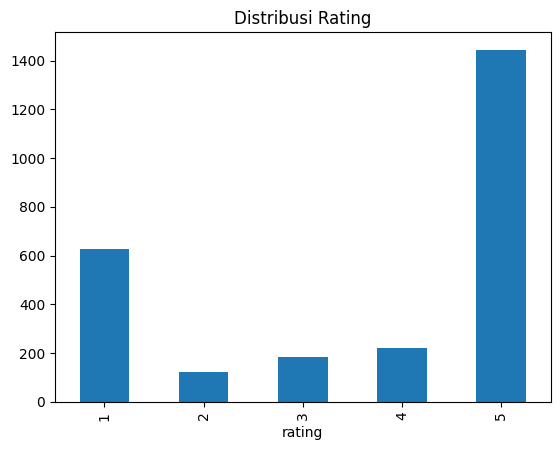

In [26]:
## DISTRIBUSI RATING
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribusi Rating")
plt.show()

In [27]:
## DATA NEGATIF
df_neg = df[df['rating'] <= 2]
print("Jumlah data negatif:", len(df_neg))

Jumlah data negatif: 750


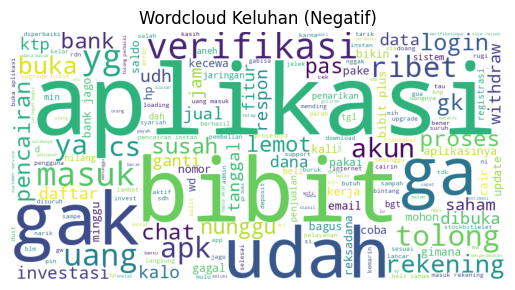

In [28]:
## WORDCLOUD
from wordcloud import WordCloud

text_neg = " ".join(df_neg['clean_review'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text_neg)

plt.imshow(wc)
plt.axis("off")
plt.title("Wordcloud Keluhan (Negatif)")
plt.show()

In [29]:
## BIGRAM
from sklearn.feature_extraction.text import CountVectorizer

def get_top_bigrams(corpus, n=15):
    vec = CountVectorizer(ngram_range=(2,2)).fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)

    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]

    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

top_bigrams = get_top_bigrams(df_neg['clean_review'])

print("\nTop Bigrams:")
for i in top_bigrams:
    print(i)


Top Bigrams:
('bibit plus', np.int64(25))
('bank jago', np.int64(23))
('masuk rekening', np.int64(18))
('beli saham', np.int64(17))
('pencairan instan', np.int64(17))
('aplikasi bibit', np.int64(15))
('upgrade bibit', np.int64(14))
('buka aplikasi', np.int64(12))
('uang masuk', np.int64(12))
('ga buka', np.int64(11))
('akun bibit', np.int64(11))
('jaringan bagus', np.int64(10))
('dana masuk', np.int64(10))
('slow respon', np.int64(9))
('tolong perbaiki', np.int64(9))


In [30]:
## TRIGRAM
def get_top_trigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(3,3)).fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)

    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]

    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

top_trigrams = get_top_trigrams(df_neg['clean_review'])

print("\nTop Trigrams:")
for i in top_trigrams:
    print(i)


Top Trigrams:
('upgrade bibit plus', np.int64(13))
('rekening bank jago', np.int64(4))
('fitur hapus akun', np.int64(3))
('periksa koneksi internet', np.int64(3))
('update bibit plus', np.int64(3))
('uang masuk rekening', np.int64(3))
('ga masuk masuk', np.int64(3))
('jual reksa dana', np.int64(3))
('uang ga masuk', np.int64(3))
('dana masuk rekening', np.int64(3))


# Visualisasi

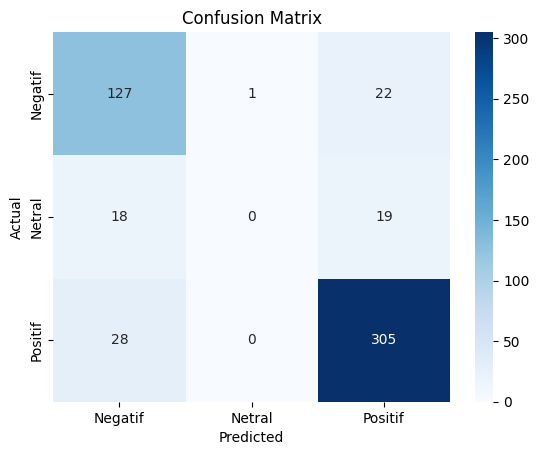

In [31]:
## CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif','Netral','Positif'],
            yticklabels=['Negatif','Netral','Positif'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

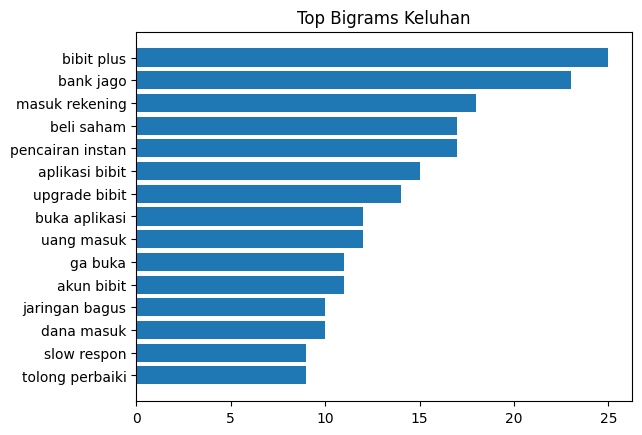

In [32]:
## BIGRAM DOMINAN PADA ULASAN NEGATIF
words = [w[0] for w in top_bigrams]
counts = [w[1] for w in top_bigrams]

plt.barh(words, counts)
plt.title("Top Bigrams Keluhan")
plt.gca().invert_yaxis()
plt.show()

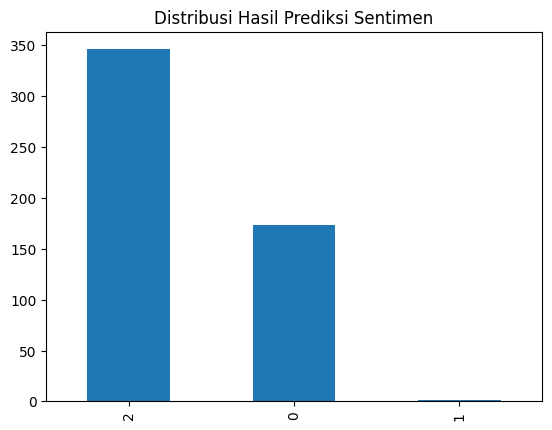

In [33]:
## DISTRIBUSI SENTIMEN
pd.Series(y_pred).value_counts().plot(kind='bar')
plt.title("Distribusi Hasil Prediksi Sentimen")
plt.show()